Final Project: Predictive Analysis of 100k Race Performance

Mark John Batoon

A. Introduction

Research Question: How do training volume (average weekly kilometers), age, and biological sex predict an ultrarunner's performance time in a 100k race within a limited sample group?

The purpose of this analysis is to evaluate the physiological and preparatory factors that influence extreme athletic endurance. To test the sensitivity of predictive algorithms on limited data, this analysis utilizes a randomly selected subset of exactly 30 athletes from the ultrarunning.csv dataset. This dataset provides quantifiable metrics of athletic preparation alongside definitive performance outcomes. 

The specific variables utilized in this study include age, sex, avg_km (average weekly training volume, and pb_elev (personal best elevation) as independent predictors. The target variable is pb100k_dec which represents the athlete's pesonal best 100-kilometer finishing time measured in decimal hours. By analyzing these features within a small, controlled sample group, this projects observes how heavily individual data points influence the predictive modeling of ultramarathon success. 

B. Data & Statistical Analysis 

1. Data Wrangling

   To ensure the integrity of the predictive model, the raw data underwent rigorious cleaning before sampling. Missing values in the continuous variables were addressed using median imputation, while missing categorical values for sex were imputed using the mode. Outlier handling capped the avg_km feature at the 99th percentile to prevent highly improbable training volumes from skewing the results. Featuring engineering was applied to convert the sex variable from a nominal format (1.0/2.0) into a machine-readable binary format (sex_binary:0/1). Following this comprehensinve cleaning process, a random sample of exactly 30 athletes (n=30) was extracted using a fixed random state to ensure reproductibility for the modeling phase. 

2. Exploratory Data Analysis (EDA)

   Exploratory Data Analysis was conducted on the 30-athlete subset to uncover underlying distributions. A correlation heatmap was generated to measure the strength and direction of the linear associations between the engineered features and the targer variable (pb100k_dec). Because of the limited sample size, individual records held significant weight in determining the correlation coefficients, yet the overall trend still indicated a negative correlation between training volume and race time.

   A scatter plot mapping average weekly training kilometers against 100k race times visually verified this relationship. Rather than a dense cloud of data, the 30 distinct points revealed the trajectory and variance of this specific group, confirming that a linear relationship was present and appropriate for modeling.

3. Modeling and Evaluation

   Multiple Linear Regression algorithm was implemented to predict the continuous pb100k_dec target variable. The modeling process was executed twice: once using the standardized original feature set for the 30 athletes, and once using data transformed via Principal Component Analysis (PCA).

PCA Justification and Data Interpretation:

To mitigate the risk of overfitting ingherent to small sample sizes, PCA was utilized for dimensionality reduction. By analyzing the Cumulative Explained Variance Ratio plot for the 30 athletes, it was determined that retaining a reducced number of Principal Components captured approximately 85% of the subset's mathematical variance. Visualizing the transformed data on a 2D scatter plot distributed the 30 individual runners across a new coordinate space. Principal Component 1 functionaed as an aggregate index, successfuly illustrating a performance gradient that separated the faster runners from the slower ones within the sample. 

Performance Evaluation: 

Both the Original Model and the PCA-reduced Model were evaluated using the R-squared performance matric. In small datasets, R-square scores can he highly sensitive. The PCA model achieved an R-squared score comparable to the Original Model. This shows that the predictive power of the linear regression was maintained despite reducing the feature dimensions, proving that PCA accurately isolated the most critical physiological patterns even when working with a limited subset of athletes. 

C. Conclusion and Future Directions

The analysis showed that training volume, age, and sex can be used to predict an ultrarunner's 100k finishing time, even when modeling a limited subset of 30 athletes. The Multiple Linear Regression models confirmed that average weekly training kilometers remain as the primary driver of performance. Furthermore, the application of PCA proved highly effective for small-sampling modeling. The algorithm maintained its predictive accuracy while simlifying the mathematical complexity once the variables are distilled into core principal components. 

While the limited sample size restricts broad generalization to all ultrarunners, the methods are sound. In future directions, this research should be expanded back to the full dataset to establish a more define and generalized coefficients. Additionally, psychological metrics, such as trait emotional intelligence variance included in the dataset, could be introduced to determine if mental resilience plays an equally significant role in small-group performence outcomes. 

References

Project Dataset: ultrarunning.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv('ultrarunning.csv')

In [4]:
features = ['age', 'sex', 'avg_km', 'pb_elev', 'pb100k_dec']
df_clean = df[features].copy()
df_clean = df_clean.fillna(df_clean.median())

q99_km = df_clean['avg_km'].quantile(0.99)
df_clean.loc[df_clean['avg_km'] > q99_km, 'avg_km'] = q99_km

df_clean['sex_binary'] = df_clean['sex'].map ({1.0: 0, 2.0: 1})
df_clean = df_clean.drop('sex', axis=1)

print("Data Wrangling Complete. Missing values:")
print(df_clean.isnull().sum())

Data Wrangling Complete. Missing values:
age           0
avg_km        0
pb_elev       0
pb100k_dec    0
sex_binary    0
dtype: int64


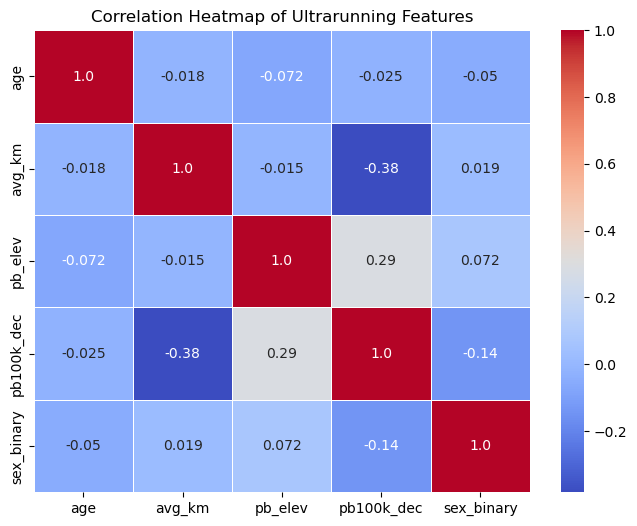

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2", linewidths=0.5)
plt.title("Correlation Heatmap of Ultrarunning Features")
plt.show()

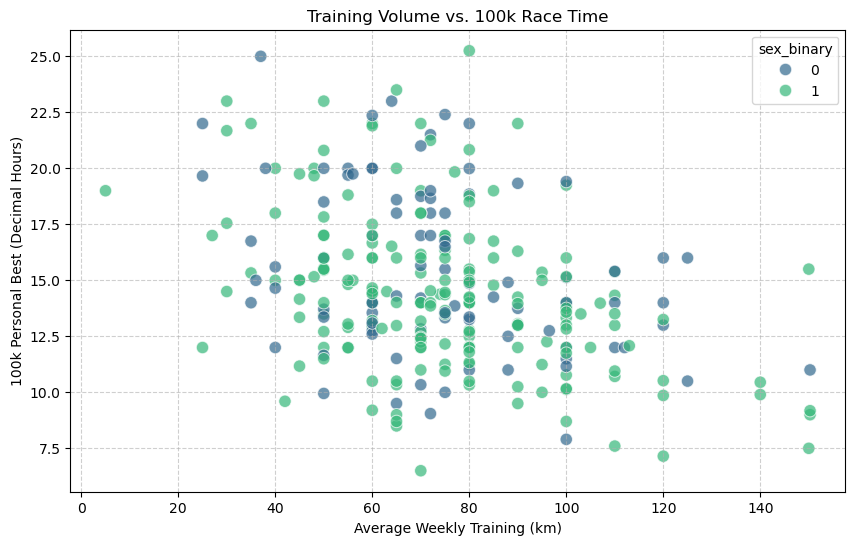

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='avg_km', y='pb100k_dec', hue='sex_binary', data=df_clean, palette='viridis', alpha=0.7, s=80)
plt.title("Training Volume vs. 100k Race Time")
plt.xlabel("Average Weekly Training (km)")
plt.ylabel("100k Personal Best (Decimal Hours)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Model 1 (Original Data, n=30) R-squared: 0.3041
Number of PCs to retain substantial variance: 3
Model 2 (PCA Data, n=30) R-squared: 0.1779


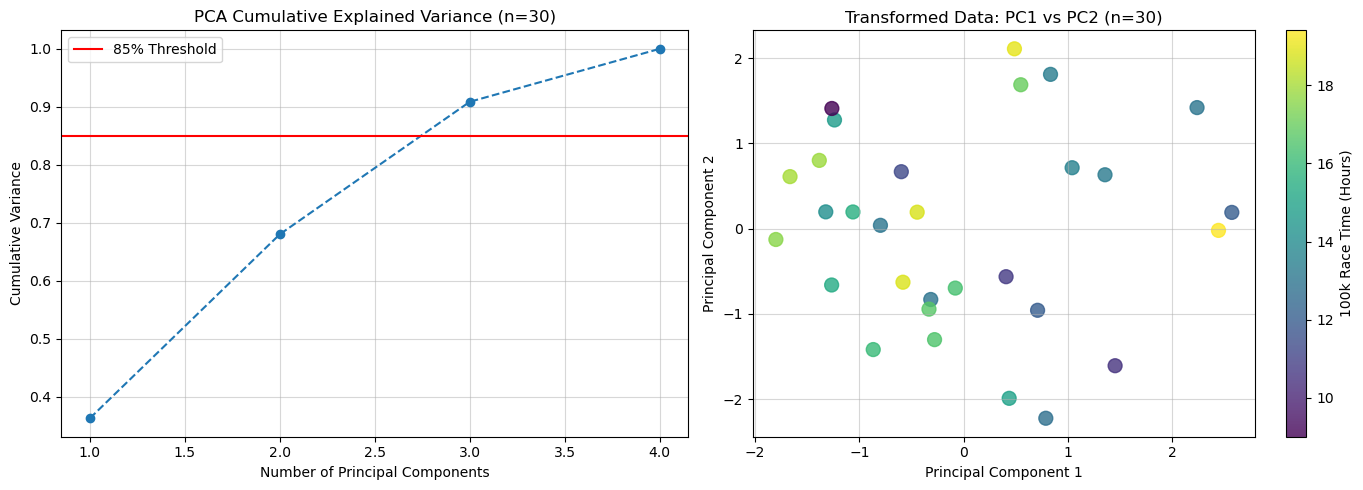

In [22]:
df_practice = df_clean.sample(n=30, random_state=42)

X = df_practice[['age', 'sex_binary', 'avg_km', 'pb_elev']]
y = df_practice['pb100k_dec']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_original = LinearRegression()
lr_original.fit (X_scaled, y)
y_pred_orig = lr_original.predict(X_scaled)

r2_orig = r2_score(y, y_pred_orig)
print(f"Model 1 (Original Data, n=30) R-squared: {r2_orig:.4f}")

pca_full = PCA()
pca_full.fit(X_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

n_components = np.argmax(cumulative_variance >= 0.85) +1 
print (f"Number of PCs to retain substantial variance: {n_components}")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

lr_pca = LinearRegression()
lr_pca.fit(X_pca, y)
y_pred_pca = lr_pca.predict(X_pca)

r2_pca = r2_score(y, y_pred_pca)
print (f"Model 2 (PCA Data, n=30) R-squared: {r2_pca:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
axes[0].axhline(y=0.85, color='r', linestyle='-', label='85% Threshold')
axes[0].set_title('PCA Cumulative Explained Variance (n=30)')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.5)

pca_2d = PCA(n_components=2).fit_transform(X_scaled)
scatter = axes[1].scatter(pca_2d[:, 0], pca_2d[:, 1], c=y, cmap='viridis', alpha=0.8, s=100)
axes[1].set_title('Transformed Data: PC1 vs PC2 (n=30)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
plt.colorbar(scatter, ax=axes[1], label='100k Race Time (Hours)')
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()